# Incorporating prior domain knowledge

In this notebook, we demonstrate how to identify biologically meaningful gene programs from single-cell RNA-seq data while refining broad gene set annotations.
The goal is to show that integrating domain knowledge from curated gene programs (Hallmark and Reactome) allows MOFA-FLEX to:
- recover known biological structure, such as interferon-stimulated responses,
- refine gene program composition in a data-driven way, and
- maintain reconstruction accuracy comparable to standard methods.

In [1]:
import re
import urllib.request
from pathlib import Path

import anndata as ad
import mofaflex as mfl
import numpy as np
import pandas as pd
import scanpy as sc
from plotnine import *
from tqdm.auto import tqdm

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



## Getting the data

We use the {cite:t}`pmid29227470` PBMC interferon-β stimulation dataset.
This is a single-cell RNA-seq dataset consisting of 13,576 PBMCs from lupus patients, either treated with interferon-β (IFN-β) or left untreated.
Since preprocessing is not the focus of this tutorial, we use [preprocessed data](https://docs.scarches.org/en/latest/expimap_surgery_pipeline_basic.html) already available in AnnData format.

In [2]:
class TqdmDownload(tqdm):
    def __init__(self, *args, **kwargs):
        kwargs = dict(kwargs)
        kwargs.update(
            {
                "unit": "B",
                "unit_scale": True,
                "unit_divisor": 1024,
                "dynamic_ncols": True,
            }
        )
        super().__init__(*args, **kwargs)
        self._have_total = False

    def update_to(self, nblocks=1, blocksize=1, total=-1):
        if not self._have_total:
            self.reset(total=total)
            self._have_total = True
        self.update(nblocks * blocksize - self.n)


outfile = Path("data/kang_tutorial.h5ad")
outfile.parent.mkdir(exist_ok=True)

with TqdmDownload(desc="downloading...") as t:
    urllib.request.urlretrieve(
        "https://drive.google.com/uc?id=1t3oMuUfueUz_caLm5jmaEYjBxVNSsfxG",
        outfile,
        t.update_to,
    )

downloading...: 0.00B [00:00, ?B/s]

We perform light preprocessing steps:
- restrict analysis to the top 3,000 most variable genes to focus on biologically informative features,
- apply a log1p transformation, a simple global-scaling and center the data per gene to stabilise variance and ensure comparable feature ranges.

In [3]:
adata = ad.read_h5ad("data/kang_tutorial.h5ad")
adata.var_names = adata.var_names.str.upper()
top_genes = adata.to_df().var().sort_values(ascending=False).iloc[:3000].index
adata = adata[:, top_genes].copy()
adata.X = adata.X - adata.X.min(axis=0)
adata.X = np.log1p(adata.X)
adata.X = adata.X / adata.X.std()
adata.X = adata.X - adata.X.mean(axis=0)
adata

AnnData object with n_obs × n_vars = 13576 × 3000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'stim', 'seurat_annotations', 'integrated_snn_res.0.5', 'seurat_clusters', 'condition', 'cell_type'

## Loading and filtering gene set annotations (gene programs)

MOFA-FLEX can leverage prior biological knowledge in the form of curated gene programs.
Here, we import and filter the Hallmark and Reactome gene set collections from MSigDB.

We retain only gene programs that:
- overlap with at least 40% of the genes present in our dataset (`min_fraction=0.4`),
- contain between 40 and 200 genes after filtering, ensuring statistical robustness, and
- are nonredundant, achieved by merging highly similar gene sets (Jaccard similarity > 0.8).

The resulting combined collection serves as structured domain knowledge, guiding MOFA-FLEX to infer interpretable latent factors that correspond to biological processes such as interferon signalling, translation, and metabolism.

In [4]:
hallmark_collection = mfl.tl.msigdb_get_features(
    category="h.all", dbver="7.5.1"
).filter(adata.var_names, min_fraction=0.4, min_count=40, max_count=200)
reactome_collection = mfl.tl.msigdb_get_features(
    category="c2.cp.reactome", dbver="7.5.1"
).filter(adata.var_names, min_fraction=0.4, min_count=40, max_count=200)
gene_set_collection = hallmark_collection | reactome_collection
gene_set_collection = gene_set_collection.merge_similar(
    metric="jaccard",
    similarity_threshold=0.8,
    iteratively=True,
)
gene_set_collection

INFO	Found 16 pairs to merge.
INFO	Found 3 pairs to merge.
INFO	Found 2 pairs to merge.
INFO	Found 0 pairs to merge. Stopping...


<FeatureSets 'h.all.v7.5.1.symbols|c2.cp.reactome.v7.5.1.symbols' with 65 feature sets>

## Prettifying gene program names for better plotting

For clarity in downstream plots, we standardise and shorten gene program names.
This helper function removes technical prefixes (e.g. `HALLMARK_`, `REACTOME_`), replaces underscores with spaces, abbreviates overly long names, and tags each entry with its database source (`[H]` for Hallmark, `[R]` for Reactome).
These formatted labels improve readability in UMAPs, heatmaps, and variance explained plots.

In [5]:
def prettify_name(
    name: str,
    mapper: dict[str, str] = None,
    abbreviation_length: int = 40,
    end_with_database: bool = True,
) -> str:
    if not isinstance(name, str):
        raise TypeError("`name` must be a string.")
    if not isinstance(abbreviation_length, int) or abbreviation_length <= 0:
        raise ValueError("`abbreviation_length` must be a positive integer.")

    # split into subparts (e.g., multiple Reactome pathways)
    parts = name.split("|")

    # if multiple Reactome parts
    if len(parts) > 1:
        # calculate max length per segment (minus separators and [R])
        available_length = abbreviation_length - (len(parts) - 1) * 3  # for ' | '
        max_per_part = max(5, available_length // len(parts))

        prettified_parts = []
        for part in parts:
            # remove prefix like "REACTOME_"
            part = re.sub(r"^[A-Z0-9]+_", "", part)

            # replace underscores
            part = part.replace("_", " ")

            # apply mapper replacements
            if mapper:
                for k, v in mapper.items():
                    part = re.sub(rf"\b{re.escape(k)}\b", v, part)

            # abbreviate
            if len(part) > max_per_part:
                part = part[:max_per_part].rstrip() + "…"

            # add Reactome tag
            part = f"{part.strip()} [R]"

            prettified_parts.append(part.title())

        return " | ".join(prettified_parts)

    # --- single-part logic (normal behavior) ---
    name = name.replace("_", " ")

    if mapper:
        for k, v in mapper.items():
            name = re.sub(rf"\b{re.escape(k)}\b", v, name)

    if len(name) > abbreviation_length:
        name = name[:abbreviation_length] + "…"

    if end_with_database:
        match = re.match(r"^(\[.*\]) (.*)", name)
        if match:
            name = f"{match.group(2)} {match.group(1)}"

    return name.title()

In [6]:
for gs in gene_set_collection:
    gs.name = prettify_name(gs.name, mapper={"HALLMARK": "[H]", "REACTOME": "[R]"})
sorted([(len(gs), gs.name) for gs in gene_set_collection])[:10]

[(41, 'Protein Secretion [H]'),
 (41, 'Regulation Of Pten Stability And Act… [R]'),
 (41, 'Tp53 Regulates Metabolic Genes [R]'),
 (42, 'Metabolism Of Polyamines [R]'),
 (44, 'Uch Proteinases [R]'),
 (45, 'Auf1 Hnrnp D0 Bind… [R] | Regulation Of Ras… [R]'),
 (45, 'Cellular Response To Hypoxia [R]'),
 (45, 'Interferon Alpha Beta Signaling [R]'),
 (45, 'The Role Of Gtse1 In G2 M Progressio… [R]'),
 (46, 'Il6 Jak Stat3 Signaling [H]')]

## Storing gene program annotations as binary mask to AnnData

We convert the curated gene program collection into a binary mask matrix,
where each column represents a gene program and each row corresponds to a gene in the dataset.
Entries are 1 if a gene belongs to a given program and 0 otherwise.

This matrix is stored in `adata.varm["annotations"]` and will later be passed to MOFA-FLEX as the domain knowledge prior, linking each gene to its associated biological program.

In [7]:
adata.varm["annotations"] = gene_set_collection.to_mask(adata.var_names.tolist()).T
assert not (adata.varm["annotations"].columns.duplicated()).any()

## Configuring and training a MOFA-FLEX model

We now instantiate and train a single-group, single-view MOFA-FLEX model on the IFN-β–stimulated PBMC dataset.
- Data input: The dataset is passed as one group (`group_1`) and one view (`view_1`) containing RNA expression values.
- Data options: We disable per-group scaling (`scale_per_group=False`) since all samples belong to the same condition and reference, and we specify the key under which the binary gene-program annotations were stored (`annotations_varm_key="annotations"`).
- Model options: The model is configured with two latent factors and a Horseshoe prior, which enforces sparsity while allowing informative loadings for genes in the provided programs.
  These two latent factors will capture information that cannot be represented using our gene program collection.
  The total number of factors in the model will thus be 67: 65 gene programs plus two uninformed factors.
- Training options: We set a fixed random seed for reproducibility.

In [8]:
model = mfl.terms.MofaFlex(
    n_factors=2,
    weight_prior=mfl.priors.InformedHorseshoe(annotations_varm_key="annotations"),
)
model.fit(
    {"group_1": {"view_1": adata}},
    likelihoods=mfl.likelihoods.Normal(scale_per_group=False),
    plot_data_overview=False,
    save_path=False,
    seed=2510302247,
)

INFO	Initializing factors using 'random' method...


  0%|                                                                                                         …

INFO 	 Guessed max_plate_nesting = 2
INFO	Training converged after 4321 epochs.


## Downstream analysis

After model training, we evaluate how much variation each inferred factor explains in the RNA expression data.
This diagnostic step quantifies the relative importance of the learned latent factors and identifies which ones capture the dominant biological signals.
- `get_r2()` returns the fraction of variance explained (R²) for each factor in each view and group,
- the factors are ranked by their variance explained, and interferon-related programs are highlighted in green,
- the top-ranked latent factors correspond to interferon-related programs, consistent with the known IFN-β stimulation biology.

In [9]:
df_r2 = model.get_r2()
df_r2_sorted = df_r2.sort_values(by="R2", ascending=False)
df_r2_sorted = df_r2_sorted.loc[~df_r2_sorted["component"].isin(["Factor 1", "Factor 2"])].reset_index(drop=True)
df_r2_sorted["has_interferon"] = np.where(
    df_r2_sorted["component"].str.lower().str.contains("interferon"), True, False
)
df_r2_sorted["component"] = pd.Categorical(
    df_r2_sorted["component"],
    categories=df_r2_sorted.sort_values("R2", ascending=True)["component"],
    ordered=True,
)
df_r2_sorted.head()

,group,view,component,R2,has_interferon
0,group_1,view_1,Interferon Signaling [R],0.024196,True
1,group_1,view_1,Inflammatory Response [H],0.020623,False
2,group_1,view_1,Interferon Gamma Response [H],0.020167,True
3,group_1,view_1,Eukaryotic Translation Initiation [R],0.016380,False
4,group_1,view_1,Interferon Alpha Response [H],0.015064,True


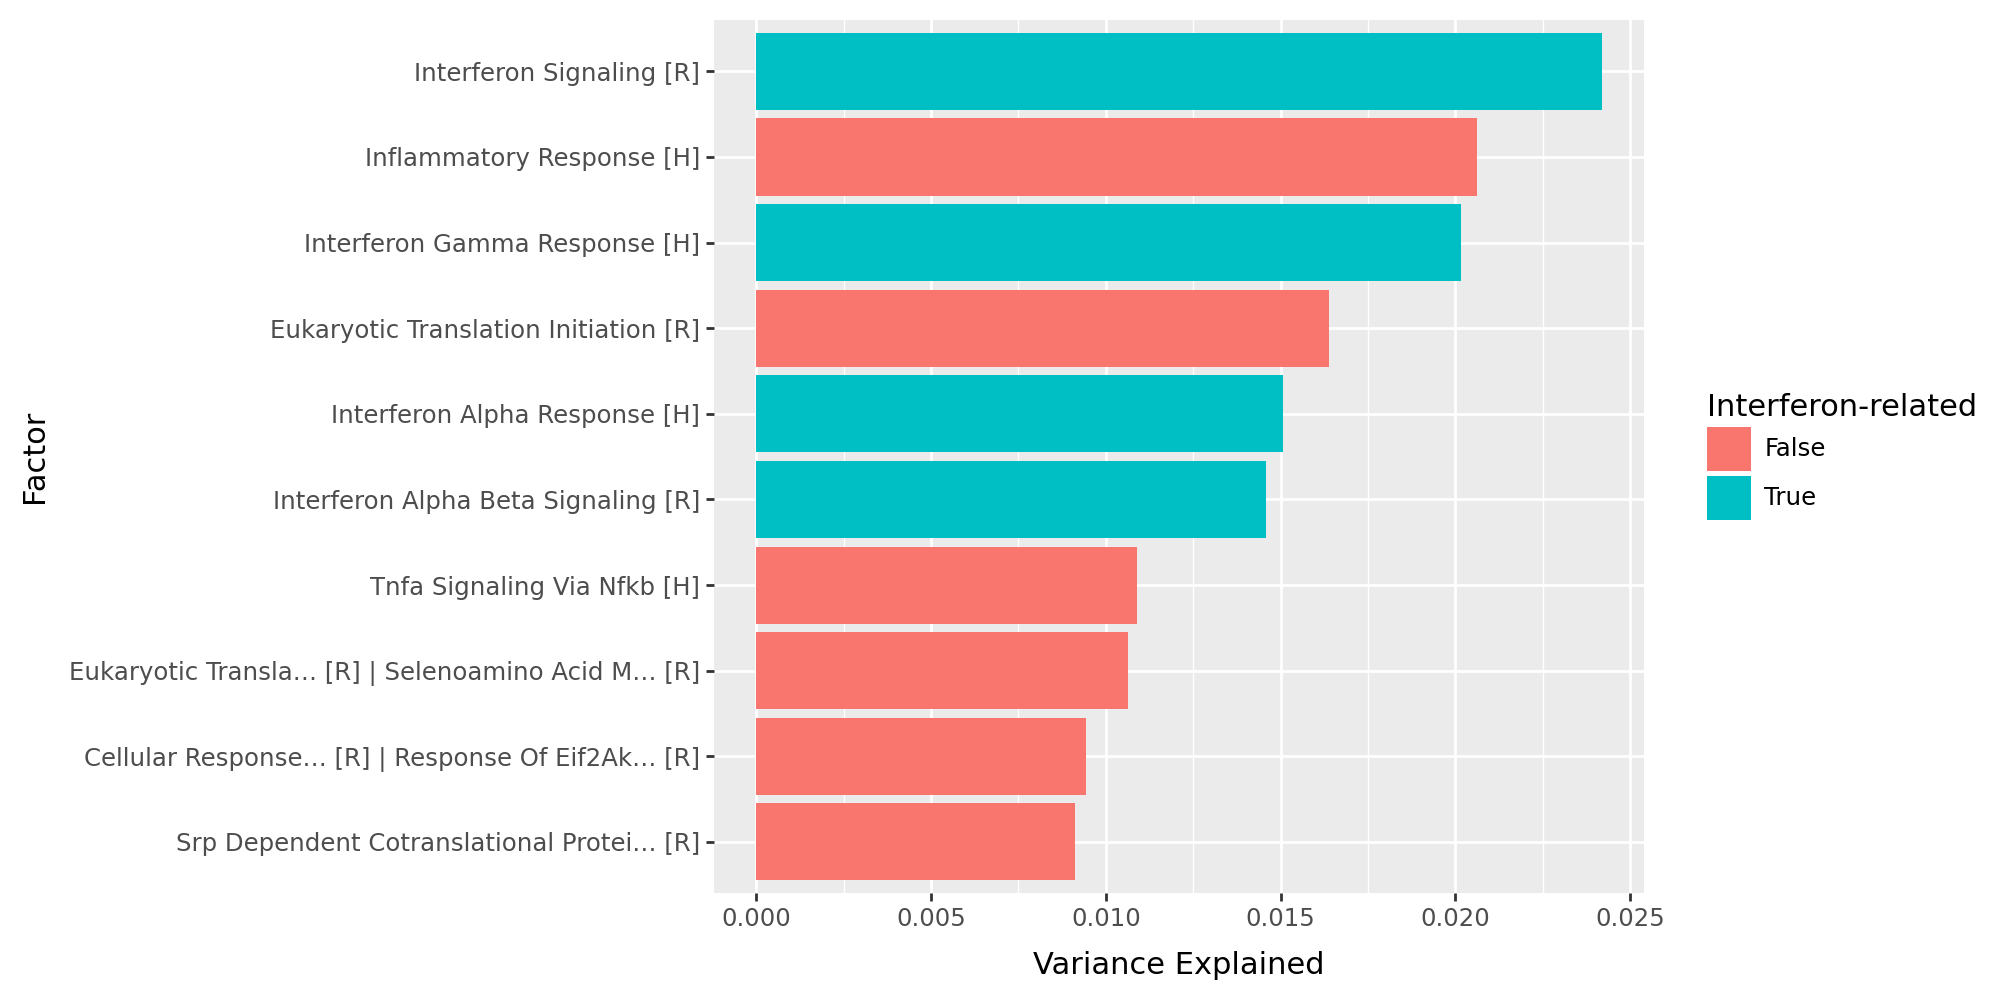

In [10]:
(
    ggplot(df_r2_sorted.head(10), aes(x="component", y="R2", fill="has_interferon"))
    + geom_bar(stat="identity")
    + labs(x="Factor", y="Variance Explained", fill="Interferon-related")
    + coord_flip()
    + theme(figure_size=(10, 5))
)

## UMAP of the latent embeddings (factors)

We next project the latent factors inferred by MOFA-FLEX into two dimensions using UMAP, enabling visual inspection of the cellular structure captured by the model.
- each point represents a cell, coloured by stimulation condition ("Control" vs. "IFN-stim"),
- the embedding is computed from the learned latent representation (`model.get_factors`), providing a biologically informed view of the data,
- the latent space cleanly separates interferon-stimulated and control cells, indicating that MOFA-FLEX successfully captures the dominant transcriptional response.

This demonstrates that incorporating prior gene-program knowledge preserves (and enhances) biological interpretability without sacrificing separation power in the latent space.

In [11]:
adata_latent = ad.AnnData(model.get_factors()["group_1"])
adata_latent.obs = adata.obs
sc.pp.neighbors(adata_latent, use_rep="X")
sc.tl.umap(adata_latent)

In [12]:
df_plot = pd.DataFrame(adata_latent.obsm["X_umap"], index=adata_latent.obs_names)
df_plot["condition"] = adata_latent.obs["condition"].map(
    {"control": "Control", "stimulated": "IFN-stim"}
)
df_plot["cell_type"] = adata_latent.obs["cell_type"]
df_plot.columns = ["UMAP1", "UMAP2", "condition", "cell_type"]

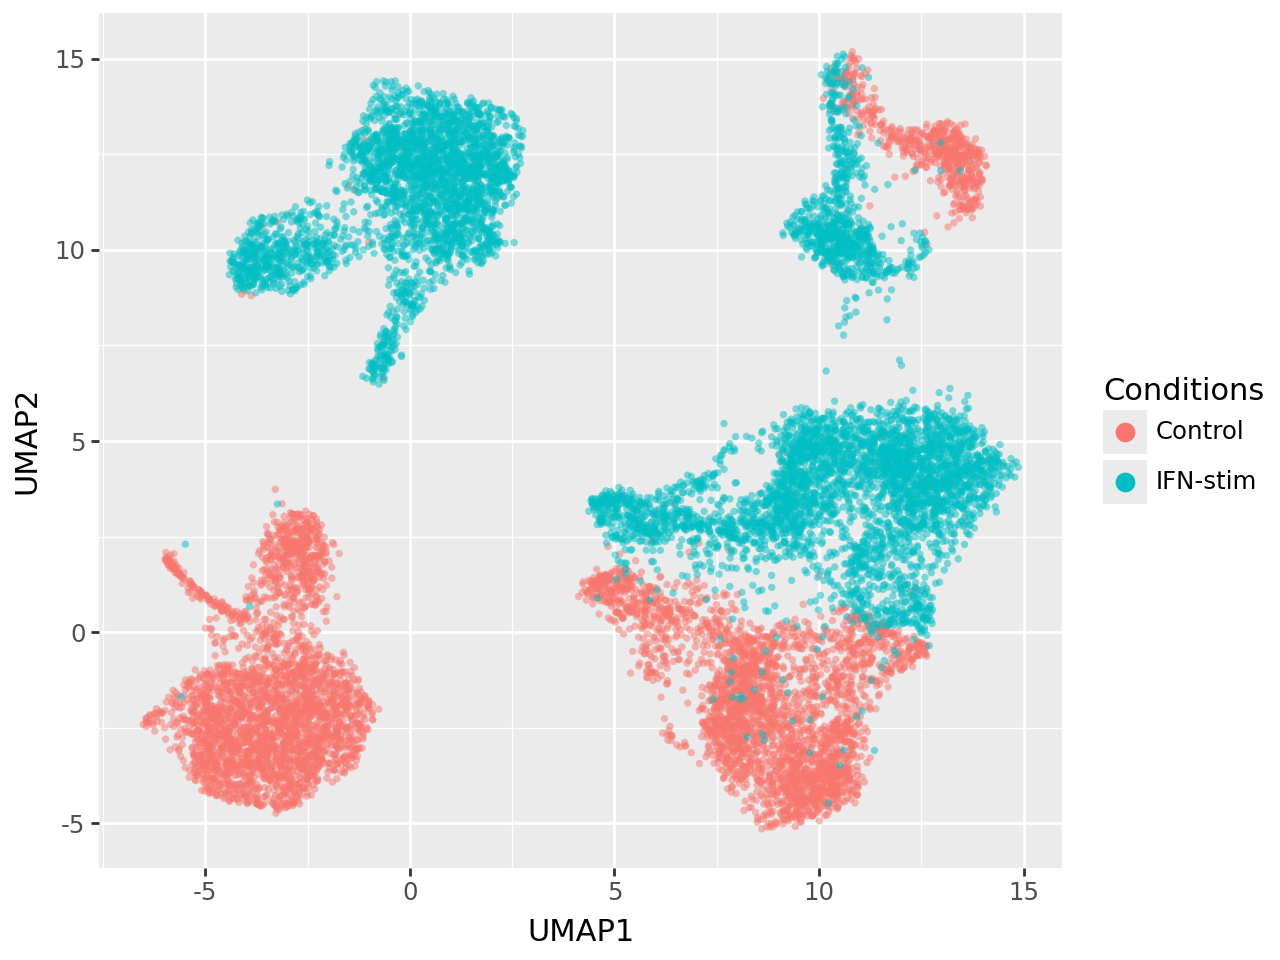

In [13]:
(
    ggplot(df_plot)
    + aes(x="UMAP1", y="UMAP2", color="condition")
    + geom_point(alpha=0.5, stroke=0)
    + labs(color="Conditions")
    + guides(color=guide_legend(override_aes={"size": 4, "alpha": 1.0}))
)

## Interpreting individual latent factors

To interpret the biological meaning of individual latent factors, we visualise the activation scores of two interferon-related gene programs, "Interferon Signaling [R]" and "Interferon Alpha Beta Signaling [R]".
Each point corresponds to a single cell, coloured by stimulation condition.
- cells stimulated with IFN-β cluster at high activation values for both factors, whereas control cells exhibit low activation,
- this alignment between model-inferred factors and experimental conditions confirms that MOFA-FLEX effectively identifies condition-specific transcriptional programs rather than generic sources of variation,
- the plot illustrates how the domain knowledge module directly links latent factors to interpretable biological processes.

In [14]:
df_plot = model.get_factors()["group_1"]
df_plot["condition"] = adata_latent.obs["condition"].map(
    {"control": "Control", "stimulated": "IFN-stim"}
)
df_plot["cell_type"] = adata_latent.obs["cell_type"]

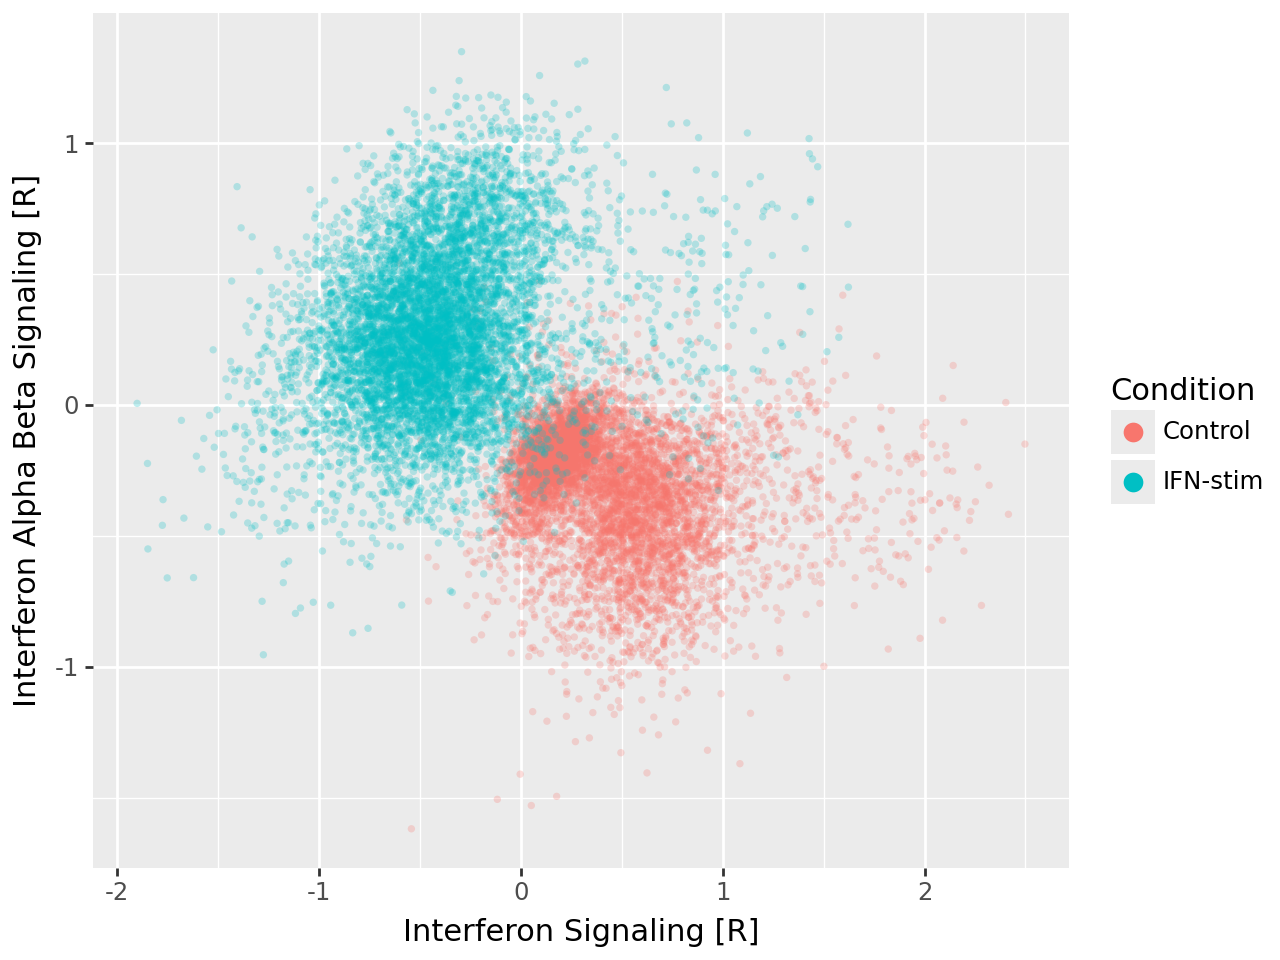

In [15]:
(
    ggplot(df_plot)
    + aes(
        x="Interferon Signaling [R]",
        y="Interferon Alpha Beta Signaling [R]",
        color="condition",
    )
    + geom_point(alpha=0.25, stroke=0)
    + labs(color="Condition")
    + guides(color=guide_legend(override_aes={"size": 4, "alpha": 1}))
)

## Inspecting the gene loadings

Next, we inspect the gene loadings associated with the most informative latent factors.
Loadings quantify each gene’s contribution to a given factor, high-weight genes define the core of the corresponding gene program.
- here we display the top 20 genes for the top-ranked factors based on variance explained,
- for interferon-related factors, canonical interferon-stimulated genes (ISGs) such as IFI6, ISG15, and OAS1 emerge with strong positive weights,
- newly inferred genes not originally annotated in the Hallmark or Reactome sets appear alongside curated ones, demonstrating how MOFA-FLEX can refine and extend gene programs in a data-driven manner.

This analysis highlights the interpretability of the learned latent factors through gene-level inspection.

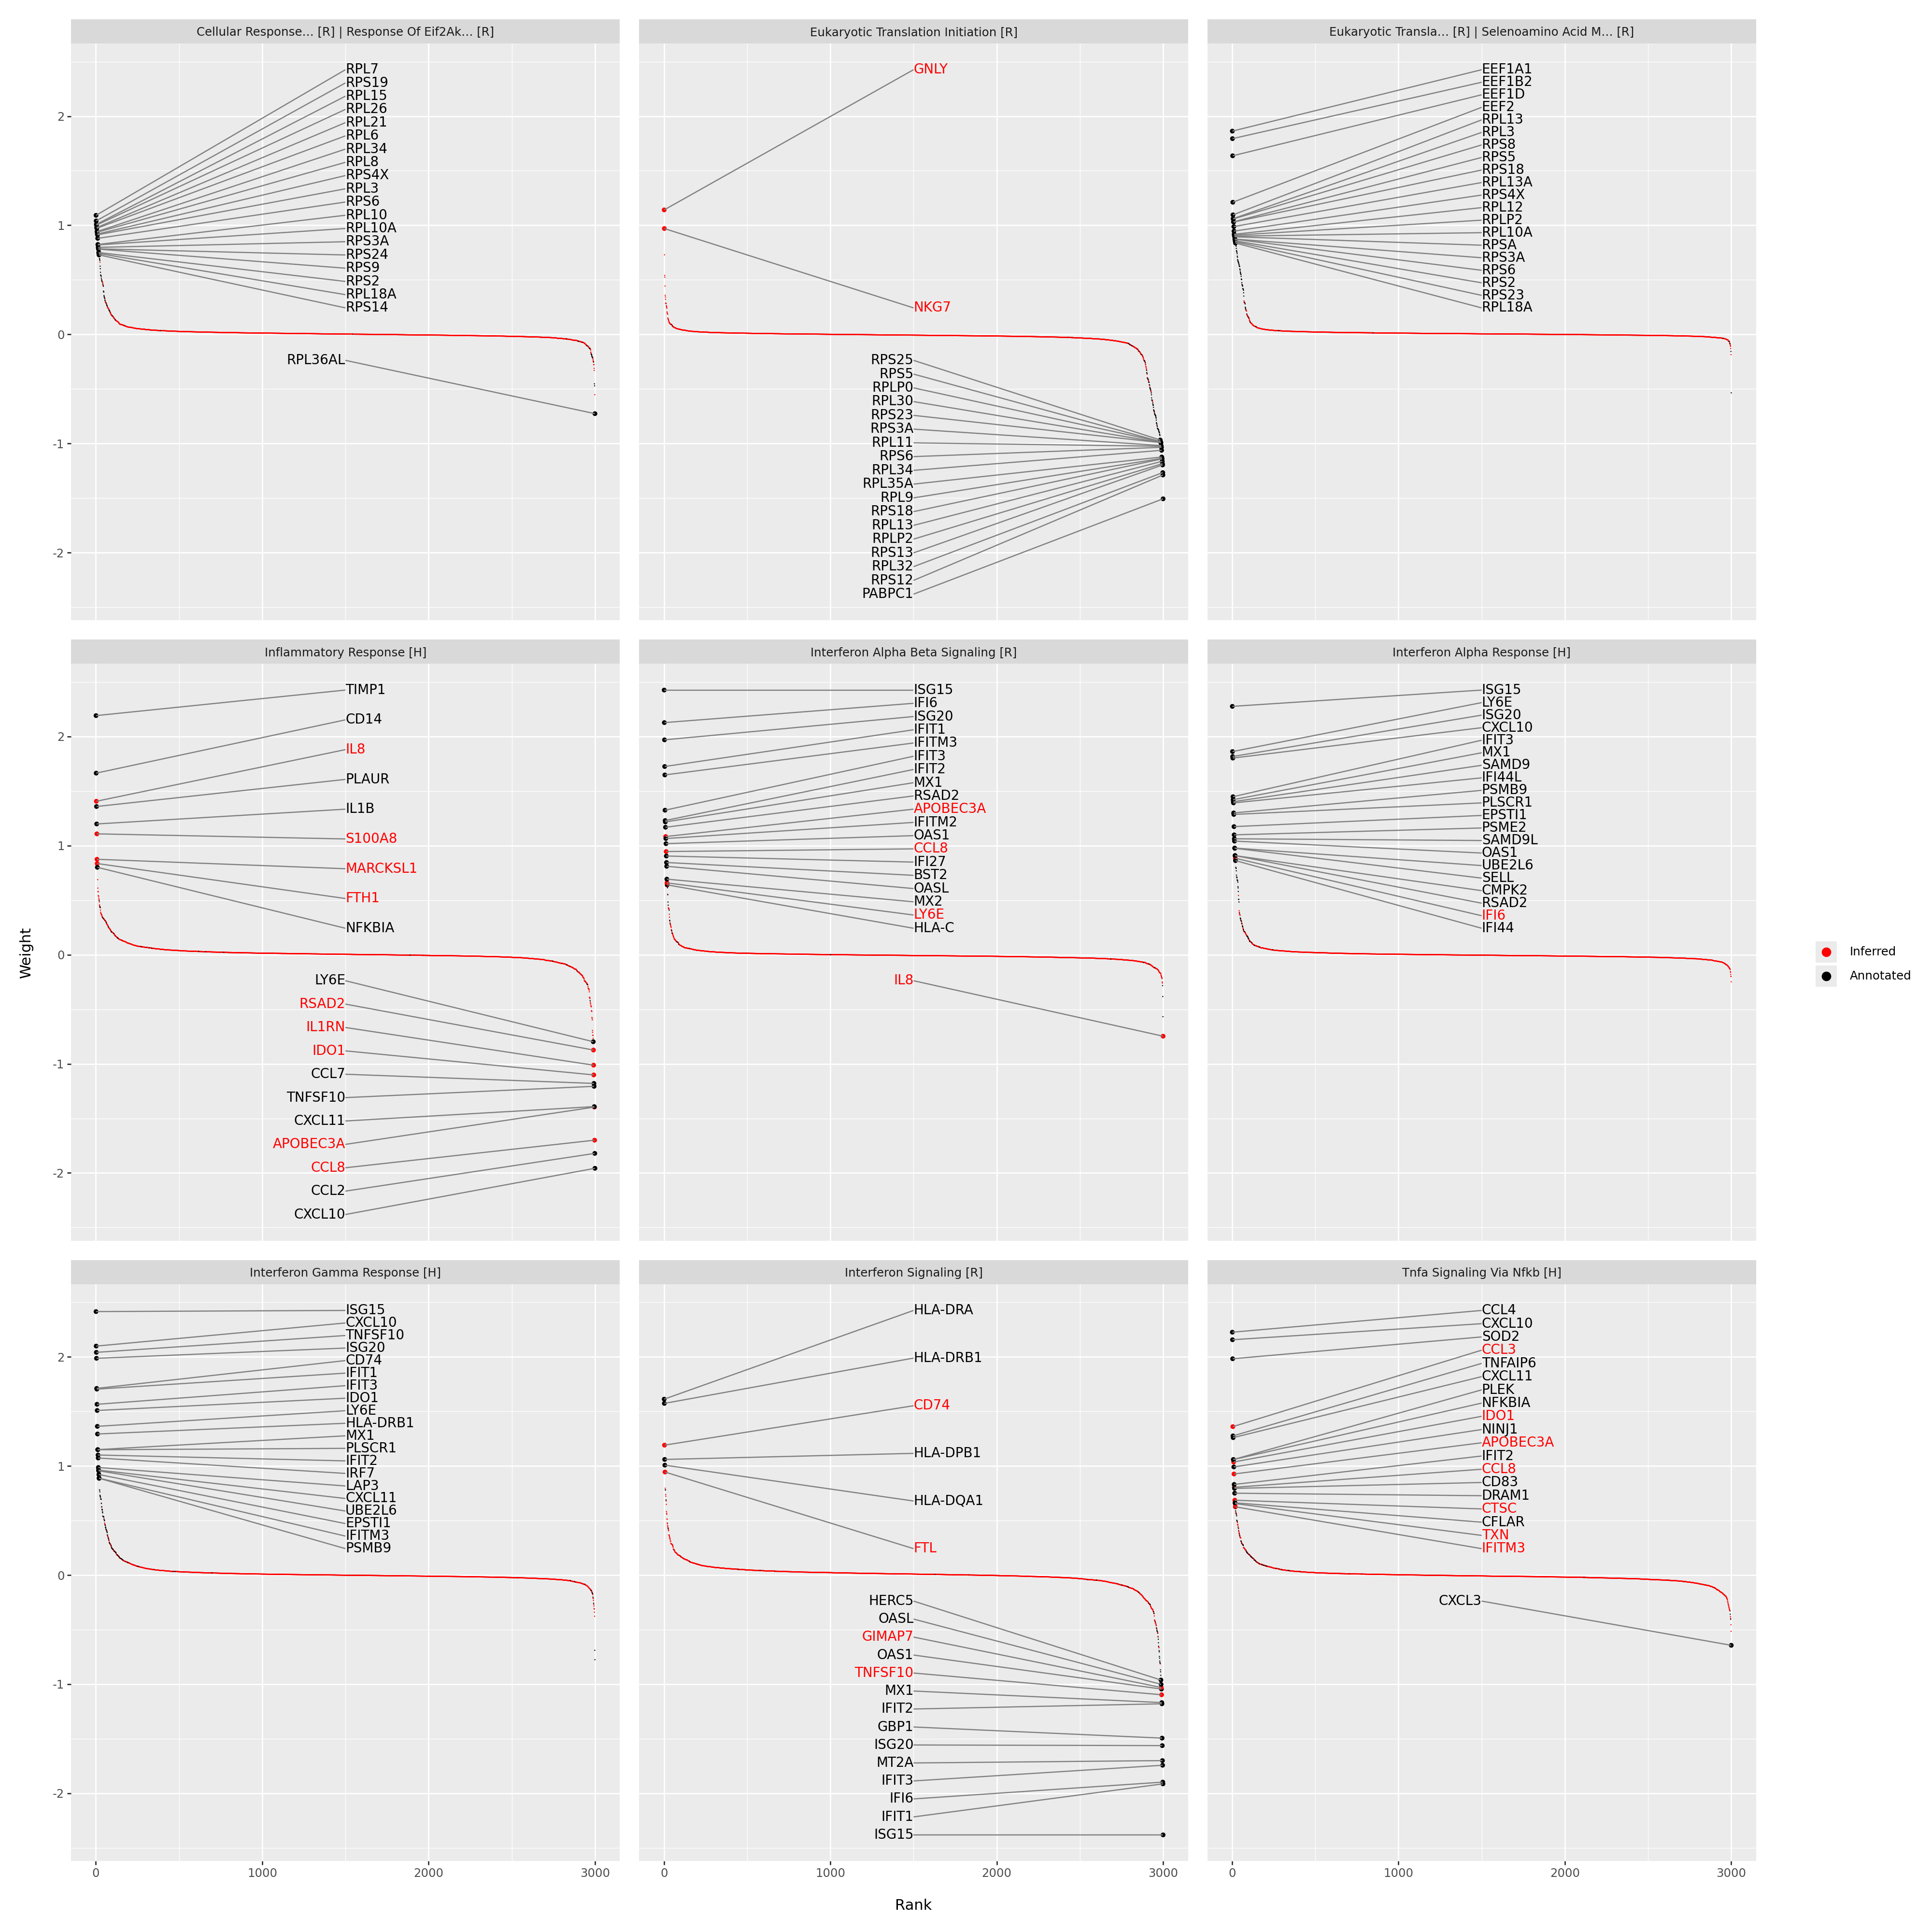

In [16]:
(
    mfl.pl.weights(
        model,
        n_features=20,
        views="view_1",
        factors=df_r2_sorted.head(9)["component"].tolist(),
        pointsize=2,
        figsize=(20, 20),
    )
    + facet_wrap("factor", ncol=3)
    + guides(color=guide_legend(override_aes={"size": 4}))
)